In [1]:
import numpy as np
import pandas as pd

## multiindexing

In [2]:
confirm=pd.read_csv('time_series_covid19_confirmed_global.csv')
globald=pd.read_csv("time_series_covid19_deaths_global.csv")

In [3]:
index_val=[('csc',2019),('csc',2020),('csc',2021),('csc',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a=pd.Series([1,2,3,4,5,6,7,8],index=index_val)
a
# in this series has one problem we cant fatch all csc items at onces

(csc, 2019)    1
(csc, 2020)    2
(csc, 2021)    3
(csc, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [4]:
# solution => multiindex series (also known  as hierarchical indexing)
# multiple index levels within single index


In [5]:
# how to create multiindex series
#1. pd.MultiIndex.from_tuple()
index_val=[('csc',2019),('csc',2020),('csc',2021),('csc',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiind=pd.MultiIndex.from_tuples(index_val)
multiind

MultiIndex([('csc', 2019),
            ('csc', 2020),
            ('csc', 2021),
            ('csc', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [6]:
# 2. pd.MultiIndex.from_product(index_val)
mulp=pd.MultiIndex.from_product([['csc','ece'],[2019,2020,2021,2022]])
mulp

MultiIndex([('csc', 2019),
            ('csc', 2020),
            ('csc', 2021),
            ('csc', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [7]:
s=pd.Series([1,2,3,4,5,6,7,8],index=multiind)
s

csc  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [8]:
s['csc']

2019    1
2020    2
2021    3
2022    4
dtype: int64

In [9]:
# unstack:- it convert multiindex series in dataframe
temp=s.unstack()
temp

,2019,2020,2021,2022
csc,1,2,3,4
ece,5,6,7,8


In [10]:
# stack :- it reconvert it into multindex series
temp.stack()

csc  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [11]:
# why we create series even we can handle it with dataframe
# because it conver higgher dimention data into lower diamention data

In [12]:

# multiindex dataframe


In [13]:
df1=pd.DataFrame([[1,2],[3,4],[5,6],[7,8],[9,10],[11,12],[13,14],[15,16]],index=multiind,columns=['avg_packeg','student'])
df1

avg_packeg  student
csc 2019           1        2
    2020           3        4
    2021           5        6
    2022           7        8
ece 2019           9       10
    2020          11       12
    2021          13       14
    2022          15       16

In [14]:
df1.loc['csc']

,avg_packeg,student
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [15]:
# multiindex df from columns perspective
df2=pd.DataFrame([[1,2,0,0],
                  [3,4,0,0],
                  [5,6,0,0],
                  [7,8,0,0]],
                  index=[2019,2020,2021,2022],
                  columns=pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','student']]))
df2 # from-product perform cartation product

delhi              mumbai        
     avg_package student avg_package student
2019           1       2           0       0
2020           3       4           0       0
2021           5       6           0       0
2022           7       8           0       0

In [16]:
df2['delhi']['avg_package']

2019    1
2020    3
2021    5
2022    7
Name: avg_package, dtype: int64

In [17]:
df2.loc[2019]

delhi   avg_package    1
        student        2
mumbai  avg_package    0
        student        0
Name: 2019, dtype: int64

In [18]:
# multiindex df in term of both cols and index
df3=pd.DataFrame([[1,2,0,0],
                  [3,4,0,0],
                  [5,6,0,0],
                  [7,8,0,0],
                  [9,10,0,0],
                  [11,12,0,0],
                  [13,14,0,0],
                  [15,16,0,0]],
                  index=multiind,
                  columns=pd.MultiIndex.from_product([['delhi','mum'],['avg_packeg','student']]))
df3

delhi                mum        
         avg_packeg student avg_packeg student
csc 2019          1       2          0       0
    2020          3       4          0       0
    2021          5       6          0       0
    2022          7       8          0       0
ece 2019          9      10          0       0
    2020         11      12          0       0
    2021         13      14          0       0
    2022         15      16          0       0

### stacking and unstacking
by stacking we can reshape our data

In [19]:
df1.unstack() #inner index become column

avg_packeg                student               
          2019 2020 2021 2022    2019 2020 2021 2022
csc          1    3    5    7       2    4    6    8
ece          9   11   13   15      10   12   14   16

In [20]:
df1.unstack().unstack() # now index become column and its become series

avg_packeg  2019  csc     1
                  ece     9
            2020  csc     3
                  ece    11
            2021  csc     5
                  ece    13
            2022  csc     7
                  ece    15
student     2019  csc     2
                  ece    10
            2020  csc     4
                  ece    12
            2021  csc     6
                  ece    14
            2022  csc     8
                  ece    16
dtype: int64

In [21]:
df1.unstack().stack().stack()# it conver inner insex of column into row

C:\Users\ankit\AppData\Local\Temp\ipykernel_28024\4225088493.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df1.unstack().stack().stack()# it conver inner insex of column into row


csc  2019  avg_packeg     1
           student        2
     2020  avg_packeg     3
           student        4
     2021  avg_packeg     5
           student        6
     2022  avg_packeg     7
           student        8
ece  2019  avg_packeg     9
           student       10
     2020  avg_packeg    11
           student       12
     2021  avg_packeg    13
           student       14
     2022  avg_packeg    15
           student       16
dtype: int64

In [22]:
df3.unstack().unstack()

delhi  avg_packeg  2019  csc     1
                         ece     9
                   2020  csc     3
                         ece    11
                   2021  csc     5
                         ece    13
                   2022  csc     7
                         ece    15
       student     2019  csc     2
                         ece    10
                   2020  csc     4
                         ece    12
                   2021  csc     6
                         ece    14
                   2022  csc     8
                         ece    16
mum    avg_packeg  2019  csc     0
                         ece     0
                   2020  csc     0
                         ece     0
                   2021  csc     0
                         ece     0
                   2022  csc     0
                         ece     0
       student     2019  csc     0
                         ece     0
                   2020  csc     0
                         ece     0
                   2

### working with multiindex dataframe

In [23]:
# head and tainl
df3.head()

delhi                mum        
         avg_packeg student avg_packeg student
csc 2019          1       2          0       0
    2020          3       4          0       0
    2021          5       6          0       0
    2022          7       8          0       0
ece 2019          9      10          0       0

In [24]:
#shape
df3.shape

(8, 4)

In [25]:
#info
df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('csc', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   (delhi, avg_packeg)  8 non-null      int64
 1   (delhi, student)     8 non-null      int64
 2   (mum, avg_packeg)    8 non-null      int64
 3   (mum, student)       8 non-null      int64
dtypes: int64(4)
memory usage: 632.0+ bytes


In [26]:
# duplicate
df3.duplicated()

csc  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [27]:
# extracting rows single
df3.loc[('csc',2020)]

delhi  avg_packeg    3
       student       4
mum    avg_packeg    0
       student       0
Name: (csc, 2020), dtype: int64

In [28]:
# multiple
df3.loc[('csc',2019):('ece',2022):2]

delhi                mum        
         avg_packeg student avg_packeg student
csc 2019          1       2          0       0
    2021          5       6          0       0
ece 2019          9      10          0       0
    2021         13      14          0       0

In [29]:
df3.iloc[0:5:2]

delhi                mum        
         avg_packeg student avg_packeg student
csc 2019          1       2          0       0
    2021          5       6          0       0
ece 2019          9      10          0       0

In [30]:
# extractin column
df3['delhi']['student']

csc  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: student, dtype: int64

In [31]:
# multiple
df3.iloc[:,1:3]

delhi        mum
         student avg_packeg
csc 2019       2          0
    2020       4          0
    2021       6          0
    2022       8          0
ece 2019      10          0
    2020      12          0
    2021      14          0
    2022      16          0

In [32]:
# extracting both
df3.iloc[[0,4],[1,2]]

,,delhi,mum
,,student,avg_packeg
csc,2019,2,0
ece,2019,10,0


In [33]:
# sort index 
# both=> decreasing => diff order
# based on one level
df3.sort_index(ascending=False)
df3.sort_index(ascending=[False,True])
df3.sort_index(level=1,ascending=False)

delhi                mum        
         avg_packeg student avg_packeg student
ece 2022         15      16          0       0
csc 2022          7       8          0       0
ece 2021         13      14          0       0
csc 2021          5       6          0       0
ece 2020         11      12          0       0
csc 2020          3       4          0       0
ece 2019          9      10          0       0
csc 2019          1       2          0       0

In [34]:
# multiindex dataframe(col)=> transpose
df3.transpose()

csc                 ece               
                 2019 2020 2021 2022 2019 2020 2021 2022
delhi avg_packeg    1    3    5    7    9   11   13   15
      student       2    4    6    8   10   12   14   16
mum   avg_packeg    0    0    0    0    0    0    0    0
      student       0    0    0    0    0    0    0    0

In [35]:
# swaplevel
df3.swaplevel()

delhi                mum        
         avg_packeg student avg_packeg student
2019 csc          1       2          0       0
2020 csc          3       4          0       0
2021 csc          5       6          0       0
2022 csc          7       8          0       0
2019 ece          9      10          0       0
2020 ece         11      12          0       0
2021 ece         13      14          0       0
2022 ece         15      16          0       0

In [36]:
df3.swaplevel(axis=1)

avg_packeg student avg_packeg student
              delhi   delhi        mum     mum
csc 2019          1       2          0       0
    2020          3       4          0       0
    2021          5       6          0       0
    2022          7       8          0       0
ece 2019          9      10          0       0
    2020         11      12          0       0
    2021         13      14          0       0
    2022         15      16          0       0

#### long vs wide data

Wide format is where we havee a single row for every data points with multiple columns to hold the values of various attributes.<br>
<br>
long format is where, for each data point we have many rows as the number ofattributes and each row contain the value of a particular attribute for a given data point.

In [10]:
# melt => convert wide data format into long data format
pd.DataFrame({'csc':[120]}).melt()

,variable,value
0,csc,120


In [11]:
pd.DataFrame({'csc':[120],'ece':[100],'mech':[50]}).melt(var_name='branch',value_name='num_student')

,branch,num_student
0,csc,120
1,ece,100
2,mech,50


In [12]:
pd.DataFrame({
    'branch':['cse','ece','mech'],
    '2020':[120,130,100],
    '2021':[520,234,44],
    '2022':[343,435,55]
}).melt(id_vars=['branch'],var_name='year',value_name='student')

,branch,year,student
0,cse,2020,120
1,ece,2020,130
2,mech,2020,100
3,cse,2021,520
4,ece,2021,234
5,mech,2021,44
6,cse,2022,343
7,ece,2022,435
8,mech,2022,55


In [13]:
globald.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [14]:
globald.shape

(289, 1081)

In [15]:
confirm.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [16]:
globald=globald.melt(id_vars=['Province/State','Country/Region','Lat','Long'],value_name='date',var_name='no of deaths')
confirm=confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],value_name='no of cases',var_name='date')

##### Pivot table
the pivot table takes simple column input ,and groups the entries into a two diamentional table that provide a multidimentional summarization of the data

In [2]:
import seaborn as sns

In [3]:
df= sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\ankit\AppData\Local\Temp\ipykernel_38028\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [8]:
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\ankit\AppData\Local\Temp\ipykernel_38028\884363850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [9]:
df.pivot_table(index='sex',columns='smoker',values='total_bill')

C:\Users\ankit\AppData\Local\Temp\ipykernel_38028\1243499625.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [11]:
#agg
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')

C:\Users\ankit\AppData\Local\Temp\ipykernel_38028\3701063555.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [9]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill',aggfunc={'total_bill':'sum'})

C:\Users\ankit\AppData\Local\Temp\ipykernel_14556\875104732.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill',aggfunc={'total_bill':'sum'})


day              Thur           Fri           Sat           Sun        
time            Lunch Dinner  Lunch  Dinner Lunch  Dinner Lunch  Dinner
sex    smoker                                                          
Male   Yes     191.71   0.00  34.16  129.46   0.0  589.62   0.0  392.12
       No      369.73   0.00   0.00   34.95   0.0  637.73   0.0  877.34
Female Yes     134.53   0.00  39.78   48.80   0.0  304.00   0.0   66.16
       No      381.58  18.78  15.98   22.75   0.0  247.05   0.0  291.54

In [10]:
# margin

df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)

C:\Users\ankit\AppData\Local\Temp\ipykernel_14556\3544124792.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum',margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


C:\Users\ankit\AppData\Local\Temp\ipykernel_14556\575195821.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill').plot()


<Axes: xlabel='sex'>

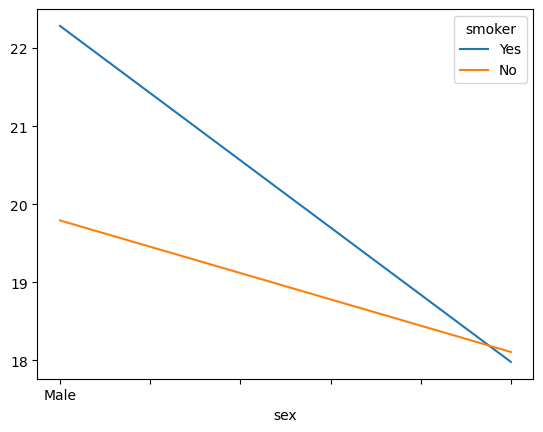

In [12]:

df.pivot_table(index='sex',columns='smoker',values='total_bill').plot()